In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
 
from afd_vmodel  import afd_vmodel
from afd_explode import afd_explode
from wavemin    import wavemin
from surround   import surround
from near import near

In [1]:
import scipy.io as sio

In [3]:
mdata = sio.loadmat('marmousi_dz10.mat')

In [6]:
mdata.keys()

dict_keys(['__header__', '__version__', '__globals__', 'x', 'z', 'vel'])

In [10]:
x = mdata['x'].ravel()
z = mdata['z'].ravel()
vel = mdata['vel']

In [16]:
dx=x[1]-x[0] #cdp interval
xmax=max(x)
zmax=max(z) #maximum line length and maximum depth
vlow=np.min(vel)
vhigh=np.max(vel)

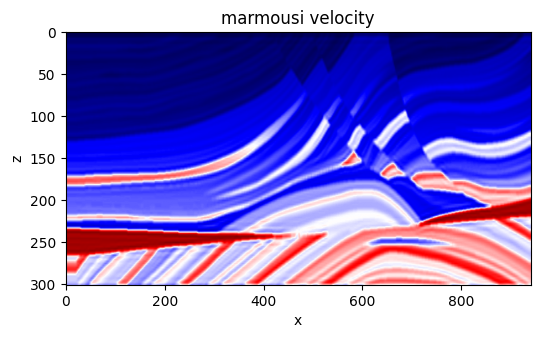

In [18]:
fig1=plt.figure(figsize=[6,6])
plt.imshow(vel, cmap='seismic', aspect=1.7)
plt.xlabel('x')
plt.ylabel('z')
plt.title('marmousi velocity')
plt.show()

In [19]:
lap=2
dt=.004 #temporal sample rate
dtstep=.001
tmax=2*zmax/vlow #maximum time
xrec=x
zrec=0*x
seisfilt,seis,t=afd_explode(dx,dtstep,dt,tmax,vel,xrec,zrec,[5, 10, 40, 50],0,lap);

There are 4083 steps to complete.
  wavefield propagated to 0.1650 s; time left ≈ 21.0 s
  wavefield propagated to 0.3300 s; time left ≈ 20.5 s
  wavefield propagated to 0.4950 s; time left ≈ 19.3 s
  wavefield propagated to 0.6600 s; time left ≈ 18.3 s
  wavefield propagated to 0.8250 s; time left ≈ 17.2 s
  wavefield propagated to 0.9900 s; time left ≈ 16.3 s
  wavefield propagated to 1.1550 s; time left ≈ 15.3 s
  wavefield propagated to 1.3200 s; time left ≈ 14.4 s
  wavefield propagated to 1.4850 s; time left ≈ 13.5 s
  wavefield propagated to 1.6500 s; time left ≈ 12.8 s
  wavefield propagated to 1.8150 s; time left ≈ 11.9 s
  wavefield propagated to 1.9800 s; time left ≈ 11.0 s
  wavefield propagated to 2.1450 s; time left ≈ 10.1 s
  wavefield propagated to 2.3100 s; time left ≈ 9.2 s
  wavefield propagated to 2.4750 s; time left ≈ 8.4 s
  wavefield propagated to 2.6400 s; time left ≈ 7.5 s
  wavefield propagated to 2.8050 s; time left ≈ 6.6 s
  wavefield propagated to 2.9700 s;

In [20]:
nx = len(x)
nz = len(z)

In [21]:
seis.shape

(1021, 941)

In [22]:
smin,smax=np.percentile(seis,[1,99])

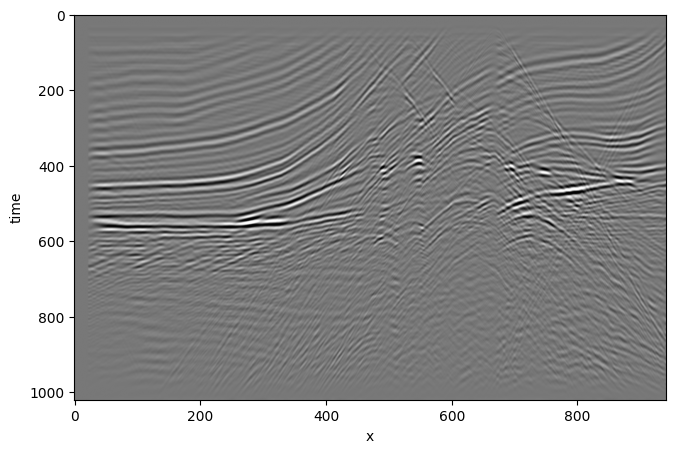

In [27]:
fig2=plt.figure(figsize=[10,5])
plt.imshow(seisfilt, cmap='gray', vmin=smin, vmax=smax,aspect=0.6)
plt.xlabel('x')
plt.ylabel('time')
plt.title('zero offset section for marmous
plt.show()